# Проект 1. Кто начитаннее: москвичи или петербуржцы?

В наличии уже предобработанные данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности в сервисе для чтения электронных книг и прослушивания аудиокниг (в целях конфиденциальности название не приводится). Необходимо проверить наличие дубликатов в идентификаторах пользователей, сравнить размеры групп, их статистики и распределение.

<b>ГИПОТЕЗА: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовим аналитическую записку, в которой опишем:
- Выбранный тип t-теста и уровень статистической значимости.
- Результат теста.
- Интерпретацию результатов.
- Возможные причины, объясняющие полученные результаты.

## Проверка гипотезы в Python и составление аналитической записки

- Автор: Трутнева Александра
- Дата: 18.05.2026

## Цели и задачи проекта

<font color='#777778'>

Цель:
    рассчитать параметры и проанализировать результаты A/B-теста, который позволит проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

- Задачи:
    - загрузить данные,
    - проанализировать размеры выборок и сравнить их,
    - исследовать основные статистические характеристики выборок,
    - визуализировать распределение времени активности в обеих группах,
    - выбрать подходящий тест,
    - рассчитать параметры тестов,
    - оценить корректность их проведения,
    - проанализировать результаты экспериментов и интерпретировать их.
</font>

## Описание данных

<font color='#777778'>

- `knigi_data.csv` — таблица с данными пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания).

- `city` — город пользователя (Москва или Санкт-Петербург).

- `puid` — идентификатор пользователя.

- `hours` — общее количество часов активности.

</font>

## Содержимое проекта

[1. Загрузка данных и знакомство с ними](#metka_1)

[2. Проверка гипотезы в Python](#metka_2)
    
[3. Аналитическая записка](#metka_3)

---

<a id='metka_1'></a>
## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем все необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

from scipy.stats import ttest_ind
from datetime import timedelta

In [2]:
# Выгружаем данные
df_knigi_original = pd.read_csv('https://...knigi_data.csv', index_col=0)

# Знакомимся с данными и изучаем общую информацию о них
df_knigi_original.head() # выводим первые строки датафрейма на экран

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [3]:
df_knigi_original.info() # выводим информацию о датафрейме
df_knigi_original.shape  # выводим количество строк и столбцов в датафрейме

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


(8784, 3)

In [4]:
# Проверяем наличие явных дубликатов
print(f'Явных дубликатов: {df_knigi_original.duplicated().sum()}')

dupl = df_knigi_original.duplicated(subset=['puid']).sum()
print(f'Строк-дубликатов по столбцу с идентификатором пользователей: {dupl}')

# Проверяем наличие неявных дубликатов (дублирующихся пользователей)
ids = df_knigi_original[df_knigi_original.duplicated(subset=['puid'])]['puid'].to_list()
df_knigi_original[df_knigi_original['puid'].isin(ids)].sort_values(by=['puid', 'hours']).head(10)

Явных дубликатов: 0
Строк-дубликатов по столбцу с идентификатором пользователей: 244


,city,puid,hours
6247,Санкт-Петербург,2637041,3.883926
35,Москва,2637041,10.317371
6274,Санкт-Петербург,9979490,1.302997
134,Москва,9979490,32.415573
6279,Санкт-Петербург,10597984,9.041320
145,Москва,10597984,42.931506
6283,Санкт-Петербург,10815097,0.323291
150,Москва,10815097,9.086655
6300,Санкт-Петербург,13626259,1.648434
187,Москва,13626259,21.104167


In [5]:
# Удаляем неявные дубликаты
df_knigi = df_knigi_original.drop_duplicates(subset=['puid'], keep=False)

drop_dupl = len(df_knigi_original) - len(df_knigi)
print(f"Удалено строк: {drop_dupl}")
print(f"Процент удалённых строк: {drop_dupl/len(df_knigi_original)*100:.2f}%")

Удалено строк: 488
Процент удалённых строк: 5.56%


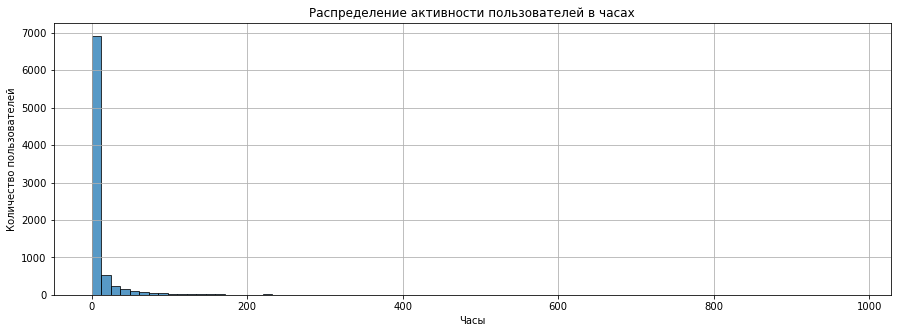

In [6]:
# Проверяем на аномалии и выбросы с помощью визуализации
plt.figure(figsize=(15, 5))
df_knigi['hours'].plot(
                        kind='hist', # тип графика — гистограмма
                        bins=80,     # количество корзин
                        alpha=0.75,
                        edgecolor='black')

# Настраиваем оформление графика
plt.title('Распределение активности пользователей в часах')
plt.xlabel('Часы')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

['Москва' 'Санкт-Петербург']
5990 2306
72.20% 27.80%


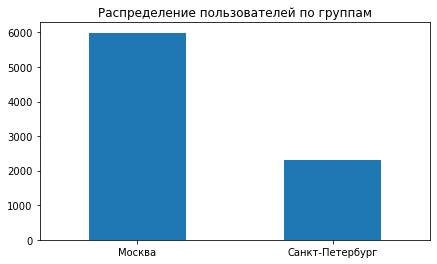

In [7]:
# Проверяем соразмерность выборок
print(df_knigi['city'].unique())

mos = df_knigi[df_knigi['city'] == 'Москва']                          # первая группа наблюдений (Москва)
spb = df_knigi[df_knigi['city'] == 'Санкт-Петербург']                 # вторая группа наблюдений (Санкт-Петербург)

print(len(mos), len(spb))                                                             # абсолютная размерность выборок
print(f'{100 * len(mos) / len(df_knigi):.2f}% {100 * len(spb) / len(df_knigi):.2f}%') # относительная размерность

# Визуализация
plt.figure(figsize=(7, 4))
df_knigi['city'].value_counts().plot(kind='bar')
plt.title('Распределение пользователей по группам')
plt.xticks(rotation=0)
plt.show()

In [8]:
# Сравниваем медианные значения часовой активности в каждом городе (первичное представление о различиях)
median_city = df_knigi.groupby('city')['hours'].median()
print(f'Медианные значения:\n{median_city}')

# Проверяем наличие неявных дубликатов по столбцу с часовой активностью
ids_hours = df_knigi[df_knigi.duplicated(subset=['hours'])]['hours'].to_list()
display(df_knigi[df_knigi['hours'].isin(ids_hours)].sort_values(by=['hours']).head(6), # первые строки (наименьшие значения)
        df_knigi[df_knigi['hours'].isin(ids_hours)].sort_values(by=['hours']).tail(6)) # последние строки (наибольшие значения)

# Считаем долю дубликатов в целом по всей выборке
total_dupl = df_knigi.duplicated(subset=['hours']).sum()
print(f'В целом: дубликатов - {total_dupl}, доля - {total_dupl / len(df_knigi) * 100:.2f}%')

# Считаем долю дубликатов внутри групп
for city in df_knigi['city'].unique():
    city_df = df_knigi[df_knigi['city'] == city]
    city_dupl = city_df.duplicated(subset=['hours']).sum()
    city_dupl_share = city_dupl / len(city_df) * 100
    print(f'{city}: дубликатов - {city_dupl}, доля - {city_dupl_share:.2f}%')

Медианные значения:
city
Москва             0.888232
Санкт-Петербург    0.875355
Name: hours, dtype: float64


,city,puid,hours
5052,Москва,1654112266,0.000028
3563,Москва,1004983713,0.000028
425,Москва,32683233,0.000028
8630,Санкт-Петербург,1945648771,0.000028
5247,Москва,1698154358,0.000028
3173,Москва,883595954,0.000028


,city,puid,hours
4871,Москва,1579986954,1.314444
7306,Санкт-Петербург,744825105,1.314444
3506,Москва,993317512,2.290000
395,Москва,30545653,2.290000
2764,Москва,735791599,4.200278
7146,Санкт-Петербург,585805522,4.200278


В целом: дубликатов - 740, доля - 8.92%
Москва: дубликатов - 453, доля - 7.56%
Санкт-Петербург: дубликатов - 164, доля - 7.11%


<div class="alert" style="color:green">
Датасет knigi_data.csv содержит 3 столбца и 8784 строки, в которых представлена информация о сумме часов активности пользователей из Москвы и Санкт-Петербурга в приложении для чтения электронных книг и прослушивания аудиокниг.

После первичного анализа данных можно сделать следующие выводы:
- На первый взгляд, значения в столбцах соответствуют своему описанию и не требуют приведения к единому виду snake case.
- Пропуски отсутствуют.
- Типы данных соответствуют содержимому.
- Проверка дубликатов показала отсутствие явных дублей, но наличие пользователей приложения как в Москве, так и в Санкт-Петербурге (неявные дубли), которые были исключены из эксперимента в обоих городах, т.к. существует условие "независимости" выборок. Теперь в таблице каждая строка соответствует уникальному пользователю. Процент удалённых строк после предобработки составил менее 6% (488 строк).
- Визуализация показывает, что распределение не является нормальным — нет «колоколообразной» кривой и преобладает левосторонняя асимметрия - «хвост» тянется вправо.
- В эксперименте 2 группы: Москва и Санкт-Петербург и между группами существует ощутимая разница в количестве уникальных пользователей (72% к 28% соответственно). Причиной этому не могут быть пользователи, которые попали в обе группы, т.к. ранее они были исключены.
- Типичный пользователь в обеих группах одинаковый, об этом говорят равные до сотого значения медианы (пользователи в Москве в среднем незначительно активнее, чем в Санкт-Петербурге).
- Доля совпадающих значений (сумма часов активности) и в целом по выборке, и по каждому городу в отдельности не превосходит 10%.
    
Вывод: учитывая, что данные с выбросами, асимметричным распределением и используемая метрика - время в приложении (hours), наиболее подходящим тестом для использования будет Тест Манна-Уитни (не использует абсолютные значения, а работает с их рангами). Тест Манна–Уитни чувствителен к повторяющимся значениям, поэтому желательно, чтобы их было меньше 10% (у нас это условие и условие независимости выполнены).
</div>

<a id='metka_2'></a>
## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [9]:
alpha = 0.05                 # уровень значимости на котором проверяем гипотезу о равенстве распределений

stat_ttest, p_value_ttest = ttest_ind(
    mos.hours,               # выборка значений метрики для группы Москва
    spb.hours,               # выборка значений метрики для группы Санкт-Петербург
    alternative='less'       # соответствует альтернативной гипотезе: Dist(mos)<Dist(spb)
)

if p_value_ttest > alpha:
    print(f'p-value={p_value_ttest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны.')
    print('Интерпретация: Средняя активность пользователей в Санкт-Петербурге не отличается от Московской.')
else:
    print(f'p-value={p_value_ttest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны, и в группе B больше')
    print('Интерпретация: Средняя активность пользователей в Санкт-Петербурге статистически значимо больше, чем в Москве.')

p-value=0.3264137070357819 > 0.05
Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны.
Интерпретация: Средняя активность пользователей в Санкт-Петербурге не отличается от Московской.


<a id='metka_3'></a>
## 3. Аналитическая записка

<div class="alert" style="color:green">
    
- Для проверки гипотезы о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы, был использован тест Стьюдента (классический t-тест) (т.к. альтернативная гипотеза о том, что выборочное среднее первой выборки меньше второй выборки).

- Уровень статистической значимости (alpha) установлен на стандартном для большинства статистических исследований уровне 0,05 (p-value > 0,05 - нулевая гипотеза не отвергается; p-value ≤ 0,05 — нулевая гипотеза отвергается в пользу альтернативной).

- По результатам теста получено значение p-value = 0.3264137070357819.
    
- Мы не можем отвергнуть нулевую гипотезу, т.к. p-value (0,324) > alpha (0,05), т.е. статистически значимых различий в средней активности пользователей между Москвой и Санкт-Петербургом не выявлено и данные не подтверждают альтернативную гипотезу о том, что пользователи из Санкт-Петербурга проводят больше времени в приложении по сравнению с пользователями из Москвы.

- Возможные причины: недостаточный объём выборки или высокая вариабельность внутри групп, не исключено, что интересы в двух городах действительно схожи.
</div>

----

# Проект 2. Битва интерфейсов: старый или новый сайт выберут покупатели?

Теперь в наличии другие данные: к нам обратились представители интернет-магазина (в целях конфиденциальности название не приводится), в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. В будущем компания хочет расширить ассортимент товаров, чтобы привлечь новых клиентов и увеличить число продаж, но интерфейс онлайн-магазина слишком сложен для пользователей (об этом говорят отзывы). Владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

## Цели и задачи проекта

<font color='#777778'>

Цель:
    Провести оценку результатов A/B-теста, оценить корректность его проведения и проанализировать результаты, имея в распоряжении данные о действиях пользователей и распределении их на группы, а также техническое задание.

- Задачи:
    - Проверить гипотезу о влиянии обновлённого интерфейса на конверсию.
    - Оценить эффективность новой версии сайта, сравнив конверсию в покупку между контрольной и тестовой группами.
    - Определить статистическую значимость различий.
    - Предоставить рекомендации команде интернет-магазина — внедрять ли новую версию сайта или дорабатывать её.
</font>

## Описание данных

<font color='#777778'>

- `ab_test_participants.csv` — таблица с данными о действиях пользователей и распределении их на группы.

- `ab_test_events.zip` — техническое задание.

</font>

## Содержимое проекта

[1. Загрузка данных и оценка их целостности](#metka_4)

[2. Оценка корректности проведения теста](#metka_5)
    
[3. Оценка результатов A/B-тестирования](#metka_6)

---

<a id='metka_4'></a>
## 1. Загрузка данных и оценка их целостности.


In [10]:
participants = pd.read_csv('https://...ab_test_participants.csv')
events = pd.read_csv('https://...ab_test_events.zip', parse_dates=['event_dt'], low_memory=False)

display(participants.head(12))   # первичный обзор
participants.info()              # информация о типах данных и наличии пропусков
display(participants.describe()) # статистика по колонкам

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
7,0031F1B5E9FBF708,A,interface_eu_test,Android
8,003346BB64227D0C,B,interface_eu_test,Android
9,00341D8401F0F665,A,recommender_system_test,iPhone


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
count,14525,14525,14525,14525
unique,13638,2,2,4
top,83AB3C13B3972BAE,A,interface_eu_test,Android
freq,2,8130,10850,6484


<div class="alert" style="color:green">
    
Датасет ab_test_participants.csv содержит 4 столбца и 14525 строк, в которых представлена информация о действиях пользователей и распределении их на группы.

После первичного анализа данных можно сделать следующие выводы:
- На первый взгляд, значения в столбцах соответствуют своему описанию и не требуют приведения к единому виду.
- Пропуски отсутствуют.
- Типы данных соответствуют содержимому.
- Имеются дубли по столбцу с идентификатором пользователя, т.к. уникальных значений по этому столбцу немного меньше общего числа строк (14525-13638=887). Дубли необходимо будет удалить, чтобы соблюсти условие "независимости" выборок.
- Распределение между группами А и В несимметричное, группа A доминирует (8130 строк из 14525).
- Большая часть тестов относится к interface_eu_test (10850 строк из 14525).
- Пользователи на Android составляют значительную часть выборки (6484 строк из 14525). Остальное распределено между iPhone, Мас и РС.
</div>

In [11]:
display(events.head(10))                           # первичный обзор
events.info()                                      # информация о типах данных и наличии пропусков
display(events.describe(datetime_is_numeric=True)) # статистика по колонке с датой
display(events.describe(include=['object']))       # статистика по текстовым колонкам

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN
5,AA346F4D22148024,2020-12-01 00:01:46,registration,-2.0
6,7EF01D0E72AF449D,2020-12-01 00:02:06,registration,-5.0
7,9A6276AD14B14252,2020-12-01 00:02:20,registration,-2.0
8,9B186A3B1A995D36,2020-12-01 00:02:37,registration,-3.5
9,9A6276AD14B14252,2020-12-01 00:02:53,login,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,event_dt
count,787286
mean,2020-12-16 18:02:17.995431424
min,2020-12-01 00:00:00
25%,2020-12-11 06:27:25.750000128
50%,2020-12-16 14:15:16.500000
75%,2020-12-22 04:28:38.249999872
max,2020-12-31 23:59:48


,user_id,event_name,details
count,787286,787286,249022
unique,144184,8,169
top,GLOBAL,login,4.99
freq,58495,248285,56063


<div class="alert" style="color:green">
    
Датасет ab_test_events.zip содержит 4 столбца и 787286 строк (достаточный объём для статистического анализа), в которых представлена информация о событиях за весь декабрь 2020 года (техническое задание).

После первичного анализа данных можно сделать следующие выводы:
- На первый взгляд, значения в столбцах соответствуют своему описанию и не требуют приведения к единому виду.
- Пропуски только в столбце с дополнительными данными о событии (заполнен этот столбец на треть).
- Типы данных соответствуют содержимому.
- Распределение событий выглядит сбалансированным по месяцу, нет явных выбросов по времени (среднее и медиана приходятся на одно число - 16 декабря).
- Имеются дубли по столбцу с идентификатором пользователя, т.к. уникальных значений по этому столбцу значительно меньше общего числа строк (787286-144184=643102). Самое частое значение - GLOBAL, что, возможно, системный идентификатор, а «выбросы» в виде системных записей делают распределение неоднородным.
- Всего 8 типов событий, событие login доминирует в данных.
</div>

<a id='metka_5'></a>
## 2. Оценка корректности проведения теста:

   2\.1 По таблице `ab_test_participants` выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет ли пользователей, участвующих одновременно в двух тестовых группах).

In [12]:
# В целях соблюдения условия "независимости", исключаем строки с пользователями, участвующими в нескольких тестах одновременно:
# 1. считаем количество дубликатов по столбцу с идентификатором пользователей
dupl2 = participants.duplicated(subset=['user_id']).sum()
print(f'Строк-дубликатов по столбцу с идентификатором пользователя: {dupl2}')

# 2. удаляем эти дубликаты
participants_clean = participants.drop_duplicates(subset=['user_id'], keep=False)

# 3. выводим статистику
drop_dupl2 = len(participants) - len(participants_clean)
print(f'Удалено строк: {drop_dupl2}')
print(f'Процент удалённых строк: {drop_dupl2 / len(participants)*100:.2f}%')
participants_clean.describe()

Строк-дубликатов по столбцу с идентификатором пользователя: 887
Удалено строк: 1774
Процент удалённых строк: 12.21%


,user_id,group,ab_test,device
count,12751,12751,12751,12751
unique,12751,2,2,4
top,0002CE61FF2C4011,A,interface_eu_test,Android
freq,1,7034,9963,5730


Количество пользователей в тесте: 9963
['A', 'B']
4952 5011
49.70% 50.30%


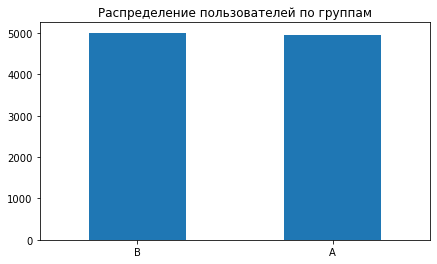

In [13]:
# Выделяем и считаем пользователей, участвующих в тесте
ab_users = participants_clean[participants_clean['ab_test'] == 'interface_eu_test']
print(f"Количество пользователей в тесте: {len(ab_users)}")

# Проверяем соразмерность выборок
print(sorted(ab_users['group'].unique()))

a = ab_users[ab_users['group'] == 'A']                   # первая группа наблюдений (контрольная)
b = ab_users[ab_users['group'] == 'B']                   # вторая группа наблюдений (новый интерфейс)

print(len(a), len(b))                                                             # абсолютная
print(f'{100 * len(a) / len(ab_users):.2f}% {100 * len(b) / len(ab_users):.2f}%') # относительная (допустимое отклонение ≤5%)

# Визуализация
plt.figure(figsize=(7, 4))
ab_users['group'].value_counts().plot(kind='bar')
plt.title('Распределение пользователей по группам')
plt.xticks(rotation=0)
plt.show()

<div class="alert" style="color:green">

Данные о пользователях, участвующих в тесте 'interface_eu_test':
- соответствуют требованиям технического задания (распределение только на две группы: А и В),
- отклонение в равномерности распределения пользователей по группам теста допустимое и меньше 5%,
- пересечения с конкурирующим тестом были исключены в количестве 1774 строк (12%).
</div>

2\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [14]:
# Здесь оставляем только события, совершенные пользователями из participants_clean
# Соединяем таблицы participants_clean и events по user_id
ab_events = events.merge(ab_users[['user_id', 'group', 'device']], on='user_id', how='inner')

# Проверяем результат
print(f"Количество событий у пользователей теста: {len(ab_events)}")
print(f"Уникальных пользователей в событиях: {ab_events['user_id'].nunique()}")

# Выводим 5 произвольных строк для проверки
ab_events.sample(5)

Количество событий у пользователей теста: 73815
Уникальных пользователей в событиях: 9963


,user_id,event_dt,event_name,details,group,device
36033,B4A5722838C7DF88,2020-12-14 12:13:54,registration,0.0,A,Mac
17580,0156BAE5D3A05F3B,2020-12-10 21:02:13,login,NaN,A,Android
39462,685315254D2E0FB6,2020-12-22 14:51:38,product_page,NaN,B,PC
14567,B08FB0C63367BA19,2020-12-10 02:08:25,login,NaN,A,Android
30151,0FA9BB5205B69038,2020-12-13 15:11:12,login,NaN,B,Android


- определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

0    37892
1     8047
2     5541
3     4103
4     3240
5     2752
6     2230
Name: life, dtype: int64

Итого 63805 событий


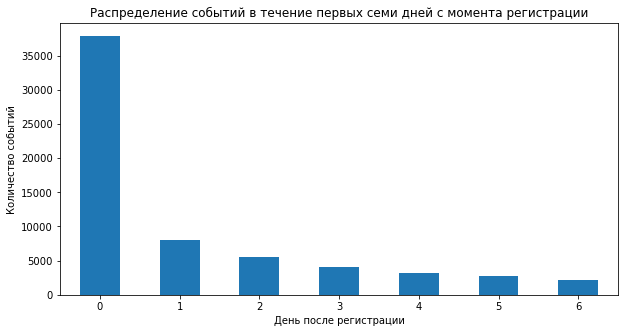

In [15]:
# Находим дату регистрации для каждого пользователя (у каждого она одна)
reg = events[events['event_name'] == 'registration'][['user_id', 'event_dt']].rename(columns={'event_dt': 'reg_dt'})

# Присоединяем даты регистрации к датафрейму с событиями, связанными с участвующими в изучаемом тесте пользователями
ab_events_reg = ab_events.merge(reg, on='user_id', how='left')

# Рассчитываем лайфтайм в днях, вычитая из даты события дату регистрации
ab_events_reg['life'] = (ab_events_reg['event_dt'] - ab_events_reg['reg_dt'])

# Отбираем события, которые были выполнены в течение первых семи дней с момента регистрации
ab_week = ab_events_reg[ab_events_reg['life'] <= timedelta(days=7)]

# Выводим распределение событий в течение первых семи дней с момента регистрации
display(ab_week['life'].dt.days.value_counts().sort_index())
sum_events = ab_week['life'].dt.days.value_counts().sort_index().sum()
print(f'Итого {sum_events} событий')

# Визуализация
plt.figure(figsize=(10, 5))
ab_week['life'].dt.days.value_counts().sort_index().plot(kind='bar')
plt.title('Распределение событий в течение первых семи дней с момента регистрации')
plt.xlabel('День после регистрации')
plt.ylabel('Количество событий')
plt.xticks(rotation=0)
plt.show()

- оценим достаточность выборки для получения статистически значимых результатов A/B-теста со следующими параметрами:

    - базовый показатель конверсии — 30%,

    - мощность теста — 80%,

    - достоверность теста — 95%.

In [16]:
# Задаём параметры
alpha = 0.05     # Уровень значимости
beta = 0.2       # Ошибка второго рода, часто 1 - мощность
power = 1 - beta # Мощность теста
p = 0.3          # Базовый уровень доли
mde = 0.1 * p    # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Считаем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1     # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [17]:
total = ab_week.groupby('group')['user_id'].nunique()                                        # количество посетителей
purchase = ab_week[ab_week['event_name'] == 'purchase'].groupby('group')['user_id'].nunique()# количество покупателей
print(f'Всего посетителей:\n {total} \n\nИз них покупателей:\n {purchase}')

Всего посетителей:
 group
A    4952
B    5011
Name: user_id, dtype: int64 

Из них покупателей:
 group
A    1377
B    1480
Name: user_id, dtype: int64


- сделаем предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

In [18]:
# Выводим абсолютную и относительную разницы в количестве посетителей
total_delta_abs = total['B']-total['A']
total_delta_otn = total_delta_abs/total['A']*100
print(f'Разница в количестве посетителей:\n   абсолютная: {total_delta_abs}\n   относительная: {total_delta_otn:.2f}%')

# Выводим абсолютную и относительную разницы в количестве покупателей
purchase_delta_abs = purchase['B']-purchase['A']
purchase_delta_otn = purchase_delta_abs/purchase['A']*100
print(f'\nРазница в количестве покупателей:\n   абсолютная: {purchase_delta_abs}\n   относительная: {purchase_delta_otn:.2f}%')

# Считаем и выводим конверсии для каждой группы
p_A = purchase['A'] / total['A']
p_B = purchase['B'] / total['B']
print(f'\nКонверсии в покупателей:\n   для контрольной группы А: {100*p_A:.2f}%\n   для тестовой группы В: {100*p_B:.2f}%')

# Считаем и выводим разницу в конверсии
print(f'\nРазница конверсий: {100*(p_B-p_A):.2f}%')

Разница в количестве посетителей:
   абсолютная: 59
   относительная: 1.19%

Разница в количестве покупателей:
   абсолютная: 103
   относительная: 7.48%

Конверсии в покупателей:
   для контрольной группы А: 27.81%
   для тестовой группы В: 29.54%

Разница конверсий: 1.73%


<div class="alert" style="color:green">

Предварительный вывод:
- Число посетителей в группе A = 4952, в B = 5011, из них покупателей в группе A = 1377, в группе B = 1480.
- Выявлено незначительное превышение количества посетителей в тестовой группе (на 59 человек, 1,19%) относительно контрольной группы, рост показателя конверсии в покупателей: с 27,81% до 29,54% (меньше 3%).
- При этом абсолютное увеличение числа покупателей в тестовой группе достигло 103 человек (7,48%) по сравнению с контрольной группой.
- Это свидетельствует о ВОЗМОЖНОМ позитивном влиянии внесённых изменений (полное обновление дизайна сайта) на активность пользователей, прежде всего на их готовность совершать покупки.
</div>

<a id='metka_6'></a>
## 3. Оценка результатов A/B-тестирования:

- Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

<div class="alert" style="color:green">

- Нулевая гипотеза (Н0): "Конверсии зарегистрированных пользователей в покупателей между группами значимо не различаются (H0: p_a = p_b)".
- Альтернативная гипотеза (H1): "Упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится в группе B по сравнению с группой A (H1: p_a < p_b)"
</div>

In [19]:
# Определяем число покупателей и посетителей для каждой группы
m_A = purchase['A']  # число покупателей в группе А
n_A = total['A']     # число посетителей в группе A

m_B = purchase['B']  # число покупателей в группе B
n_B = total['B']     # число посетителей в группе B

# Расчитываем доли
p_A = m_A / n_A
p_B = m_B / n_B

# Проверяем предпосылку о достаточном количестве данных
if (p_A*n_A>10) and ((1-p_A)*n_A>10) and (p_B*n_B>10) and ((1-p_B)*n_B> 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

# Проводим Z-тест пропорций
stat, p_value = proportions_ztest([m_A, m_B], [n_A, n_B], alternative='smaller') # т.к. H1: p_a < p_b

# Выводим полученное p-value 
print(f'pvalue={p_value}')

if p_value > alpha:
    print('Нулевая гипотеза находит подтверждение! Различия не являются статистически значимыми')
else:
    print('Нулевая гипотеза не находит подтверждения! Различия статистически значимы. Изменение в группе B повлияло на метрику')

# Интерпретация
print(f'''\nВероятность, что упрощение интерфейса интернет-магазина приведёт к тому, что в течение семи дней после регистрации
в системе конверсия зарегистрированных пользователей в покупателей увеличится есть.''')

Предпосылка о достаточном количестве данных выполняется!
pvalue=0.028262547212292124
Нулевая гипотеза не находит подтверждения! Различия статистически значимы. Изменение в группе B повлияло на метрику

Вероятность, что упрощение интерфейса интернет-магазина приведёт к тому, что в течение семи дней после регистрации
в системе конверсия зарегистрированных пользователей в покупателей увеличится есть.


<div class="alert" style="color:green">

Вывод:
- Необходимый размер выборки для каждой гуппы - 3761 пользователь.
- Условие о достаточном количестве наблюдений для применения Z-теста выполняется, поэтому выборка достаточна для надёжного статистического анализа.
- Проведён односторонний Z-тест, т.к. альтернативная гипотеза H1 утверждает, что конверсия в группе B выше, чем в группе A (p_a<p_b).
- При переходе к новой версии сайта интернет-магазина были обнаружены статистически значимые различия в конверсии зарегистрированных пользователей в покупателей между группами A и B.
- pvalue=0.0283, что не превосходит alpha=0.05, поэтому нулевая гипотеза не находит подтверждение.
</div>

<div class="alert" style="color:green">

Рекомендации:
- Новый упрощённый интерфейс стоит рассмотреть к внедрению (различия конверсии значимы, изменения в интерфейсе работают), НО необходимо учесть, что целевой показатель (увеличение конверсии как минимум на 3%) не достигнут — конверсия выросла, но не настолько, как предполагалось в гипотезе (1,73%).
</div>